# Regression Project

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("tehran.csv")
df.tail()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
3474,86,2,True,True,True,Southern Janatabad,3.500000e+09,116666.67
3475,83,2,True,True,True,Niavaran,6.800000e+09,226666.67
3476,75,2,False,False,False,Parand,3.650000e+08,12166.67
3477,105,2,True,True,True,Dorous,5.600000e+09,186666.67
3478,82,2,False,True,True,Parand,3.600000e+08,12000.00


In [3]:
df["Parking"] = df["Parking"].astype(int)
df["Warehouse"] = df["Warehouse"].astype(int)
df["Elevator"] = df["Elevator"].astype(int)
df = df.drop(["Price"], axis=1)
df

,Area,Room,Parking,Warehouse,Elevator,Address,Price(USD)
0,63,1,1,1,1,Shahran,61666.67
1,60,1,1,1,1,Shahran,61666.67
2,79,2,1,1,1,Pardis,18333.33
3,95,2,1,1,1,Shahrake Qods,30083.33
4,123,2,1,1,1,Shahrake Gharb,233333.33
...,...,...,...,...,...,...,...
3474,86,2,1,1,1,Southern Janatabad,116666.67
3475,83,2,1,1,1,Niavaran,226666.67
3476,75,2,0,0,0,Parand,12166.67
3477,105,2,1,1,1,Dorous,186666.67


<h3>for each zone of tehran we create a feature and remove the ones that are less than 5 to avoid overfitting<h3>

In [4]:
df = df.dropna(subset=["Address"])
df = df.groupby("Address").filter(lambda x: len(x) > 5)
df = pd.get_dummies(df, columns=["Address"], drop_first=True)
df.dtypes

Area                              object
Room                               int64
Parking                            int64
Warehouse                          int64
Elevator                           int64
                                   ...  
Address_West Ferdows Boulevard     uint8
Address_West Pars                  uint8
Address_Yousef Abad                uint8
Address_Zafar                      uint8
Address_Zaferanieh                 uint8
Length: 95, dtype: object

### clear the dataset

In [5]:
df["Area"] = pd.to_numeric(df["Area"], errors="coerce")
df = df.dropna(subset=["Area"])
df = df[df["Area"] < 1000]
cdf = df[["Area", "Room", "Parking", "Warehouse", "Elevator", "Price(USD)"]]

In [6]:
df[["Area","Room","Parking","Warehouse","Elevator","Price(USD)"]].corr()

,Area,Room,Parking,Warehouse,Elevator,Price(USD)
Area,1.000000,0.669063,0.198700,0.077312,0.070271,0.718815
Room,0.669063,1.000000,0.275293,0.123777,0.194410,0.559384
Parking,0.198700,0.275293,1.000000,0.446452,0.422305,0.191798
Warehouse,0.077312,0.123777,0.446452,1.000000,0.198735,0.111005
Elevator,0.070271,0.194410,0.422305,0.198735,1.000000,0.133605
Price(USD),0.718815,0.559384,0.191798,0.111005,0.133605,1.000000


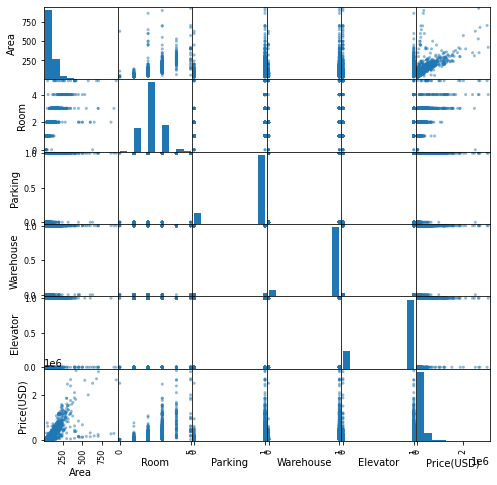

In [7]:
pd.plotting.scatter_matrix(cdf, figsize=(8,8))
plt.show()

## first we try Multiple Linear Regression (including the zones)

In [8]:
msk = np.random.rand(len(df)) < 0.8
train = df[msk]
test = df[~msk]

In [9]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
X = np.array(train.drop(["Price(USD)"], axis=1))
y = np.array(train[["Price(USD)"]])
regr.fit(X,y)
print(regr.coef_)

[[    2230.71815726    10511.43415166   -19743.33191582   -10233.12053367
     -7684.40040106 -1003236.18850789   -78914.24563292   -66206.59305297
   -140442.3852699    -61401.77155268  -130570.89445835   138617.51771284
     36386.77535399   -51429.77552116  -167201.0162188    -62527.42262641
    -16162.72242079  -424714.2168155    -76128.92646867   132457.54914018
    232634.69113073   -23193.80921145   -24418.68524871    14362.61246665
     94716.22968904   438223.03505624   -56588.28908419   325186.10958845
    -32022.93304778    86520.57538823    41963.00240988     1708.10939727
   -100798.89249011   -41091.90044814     8408.65725736   -70531.88928958
   -115581.42263761   -54732.82758377   -29618.18587694  -143779.47650845
    298477.39243786   -46609.5780132    -46977.80604159   -47050.63656946
     18223.13920162   -41337.45522353   115609.66621648   -10474.98877187
    287533.6109892      7212.06180684  -109659.0914498    -33705.8447106
    -48328.69455719   -52766.07785413  

In [10]:
from sklearn.metrics import r2_score
y_hat = regr.predict(test.drop(["Price(USD)"], axis=1))
X = np.array(test.drop(["Price(USD)"], axis=1))
y = np.array(test[["Price(USD)"]])
print(f"MSE: {np.mean((y_hat - y)**2):.2f}")
print(r2_score(y, y_hat))

MSE: 23445782778.89
0.7073310998665447


## now we try log form 

In [11]:
df["Price_log"] = np.log(df["Price(USD)"])

In [12]:
from sklearn.model_selection import train_test_split
X = df.drop(["Price(USD)", "Price_log"], axis=1)
y = df["Price_log"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

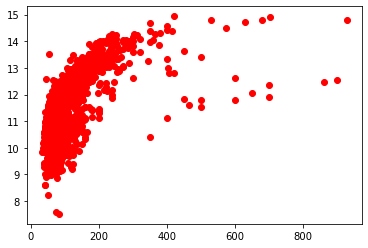

In [13]:
plt.scatter(X_train["Area"], y_train, color='red')
plt.plot()
plt.show()

In [14]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
model.coef_

array([ 0.00436181,  0.2836484 ,  0.21682444, -0.04821565,  0.15141622,
       -1.77165754, -0.78538944, -0.32442199, -0.4065455 , -0.78881055,
       -1.32062642,  0.60387843,  0.51540819, -0.58181597, -1.38790687,
       -0.8926867 , -0.14536323, -1.38082132, -0.24915743,  0.5481658 ,
        0.42357799, -0.21800146, -0.55377789,  0.07211102,  0.29403348,
        0.79699029, -1.05428654,  0.7247541 , -0.22110281,  0.46199109,
        0.37722918,  0.14840559, -1.02308791, -0.69437478,  0.23781642,
       -0.78320541, -1.21727217, -0.7341704 ,  0.21656569, -1.3224365 ,
        0.85776175, -0.74579212, -0.79203438, -0.02405713,  0.31512317,
        0.18532649,  0.40554047, -0.16175735,  0.73988906, -0.13287735,
       -1.51405082, -0.11770158, -0.18575647, -0.63885453, -0.31891623,
       -1.75069477, -2.01665673, -0.53218233, -1.79724373,  0.37130556,
       -0.814987  , -0.50815863, -0.12198711,  0.21147077, -0.70911392,
       -0.92850256, -0.40145656, -0.82138551, -1.23774719, -0.92

In [15]:
y_pred_log = model.predict(X_test)
y_pred = np.exp(y_pred_log)
y_test_real = np.exp(y_test)

In [16]:
from sklearn.metrics import r2_score

print(f"MSE: {np.mean((y_pred - y_test_real)**2):.2f}")
print(r2_score(y_test_real, y_pred))

MSE: 15001507205.55
0.7743912304234899


## Prediction

In [17]:
x_to_predict = pd.DataFrame(columns=X_train.columns)
x_to_predict.loc[0] = 0
x_to_predict["Area"] = 140
x_to_predict["Room"] = 2
x_to_predict["Parking"] = True
x_to_predict["Warehouse"] = True
x_to_predict["Elevator"] = False
x_to_predict["Address_Niavaran"] = 1
y_pred_log = model.predict(x_to_predict)
y_pred = np.exp(y_pred_log)
y_pred


array([308844.5481662])